# Global Air Quality - Unsupervised Clustering

### Project Objective

The objective of this project is to analyze the Global Air Quality dataset using unsupervised machine learning techniques. The project focuses on performing data exploration, cleaning, preprocessing, feature selection, and scaling to identify meaningful patterns in air quality data. K-Means, Hierarchical Clustering, and DBSCAN algorithms are applied to discover natural groups within the dataset. The clustering results are evaluated using Silhouette Score and Davies-Bouldin Index, followed by visualization and interpretation of the identified clusters. Finally, an automated machine learning pipeline is developed and saved for future use.

### Dataset Description

* Dataset: Global Air Quality Dataset
* Rows: 18,000
* Columns: 15
* Data Type: Air Quality & Environmental Data
* Main Features: PM2.5, PM10, NO₂, SO₂, O₃, CO, AQI, Temperature, Humidity, Wind Speed
* Purpose: To identify similar air quality patterns using clustering techniques.

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

from scipy.cluster.hierarchy import dendrogram, linkage

### Load Dataset

In [2]:
df = pd.read_csv("globalAirQuality.csv")

In [3]:
df.head()

,timestamp,country,city,latitude,longitude,pm25,pm10,no2,so2,o3,co,aqi,temperature,humidity,wind_speed
0,2025-11-04 18:25:17.554219,US,New York,40.713,-74.006,50.295,108.938,27.998,6.539,52.568,1.096,108,18.504,70.168,3.725
1,2025-11-04 19:25:17.554219,US,New York,40.713,-74.006,32.083,63.043,36.120,4.021,43.536,1.075,90,5.838,80.088,8.969
2,2025-11-04 20:25:17.554219,US,New York,40.713,-74.006,42.250,82.553,26.935,9.538,23.320,0.977,84,31.833,62.783,9.650
3,2025-11-04 21:25:17.554219,US,New York,40.713,-74.006,30.403,79.951,63.536,7.609,31.369,0.230,158,23.140,89.153,8.956
4,2025-11-04 22:25:17.554219,US,New York,40.713,-74.006,21.083,66.423,38.997,6.919,45.615,1.085,97,13.632,76.499,4.017


In [4]:
df.shape

(18000, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   timestamp    18000 non-null  object 
 1   country      18000 non-null  object 
 2   city         18000 non-null  object 
 3   latitude     18000 non-null  float64
 4   longitude    18000 non-null  float64
 5   pm25         18000 non-null  float64
 6   pm10         18000 non-null  float64
 7   no2          18000 non-null  float64
 8   so2          18000 non-null  float64
 9   o3           18000 non-null  float64
 10  co           18000 non-null  float64
 11  aqi          18000 non-null  int64  
 12  temperature  18000 non-null  float64
 13  humidity     18000 non-null  float64
 14  wind_speed   18000 non-null  float64
dtypes: float64(11), int64(1), object(3)
memory usage: 2.1+ MB


In [6]:
df.describe()

,latitude,longitude,pm25,pm10,no2,so2,o3,co,aqi,temperature,humidity,wind_speed
count,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000
mean,23.065980,37.655560,40.369131,70.152228,32.055176,6.035508,48.065100,0.800595,104.645556,21.510251,57.714351,5.283910
std,26.156536,78.600701,17.647450,24.999440,13.820680,2.454790,14.950849,0.250254,25.616070,9.509444,18.844908,2.741712
min,-37.814000,-123.121000,0.025000,0.061000,0.013000,0.003000,0.114000,0.000000,16.000000,5.000000,25.002000,0.500000
25%,12.972000,2.352000,27.904500,53.125500,22.362500,4.360750,38.028500,0.633000,87.000000,13.357750,41.320000,2.937000
50%,29.232000,42.146000,40.286500,69.961000,32.019500,6.026000,48.142000,0.800500,103.000000,21.455500,57.847000,5.297000
75%,41.008000,103.820000,52.436250,87.256500,41.364250,7.715250,58.258500,0.969000,121.000000,29.688250,74.234750,7.662000
max,60.170000,174.763000,115.683000,161.810000,90.019000,16.559000,103.016000,1.832000,231.000000,37.998000,89.997000,9.999000


In [7]:
df.isnull().sum()

timestamp      0
country        0
city           0
latitude       0
longitude      0
pm25           0
pm10           0
no2            0
so2            0
o3             0
co             0
aqi            0
temperature    0
humidity       0
wind_speed     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis (EDA)

#### AQI Distribution

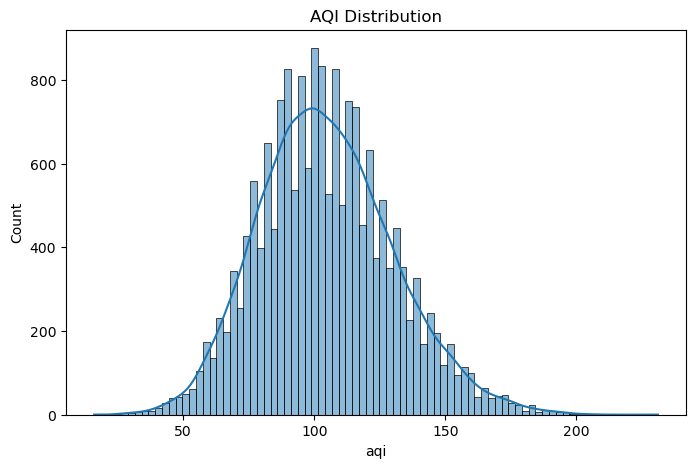

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df["aqi"], kde=True)
plt.title("AQI Distribution")
plt.show()

#### PM2.5 Distribution

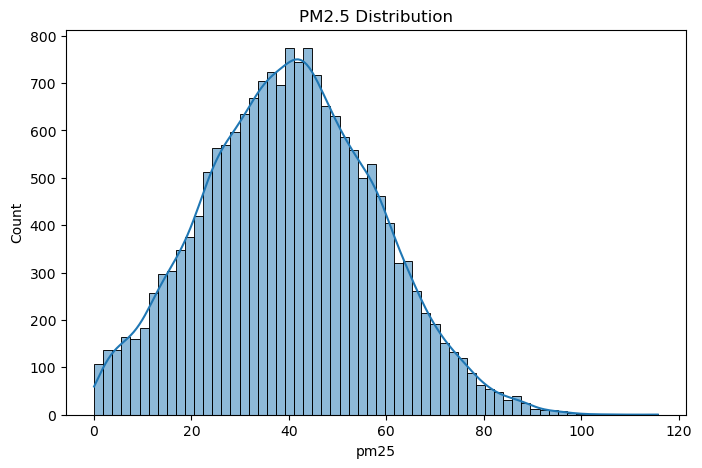

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["pm25"], kde=True)
plt.title("PM2.5 Distribution")
plt.show()

#### PM10 Distribution

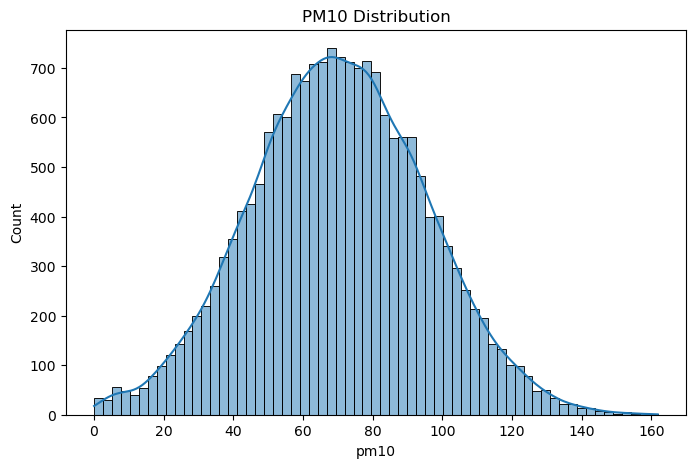

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["pm10"], kde=True)
plt.title("PM10 Distribution")
plt.show()

### Correlation Heatmap

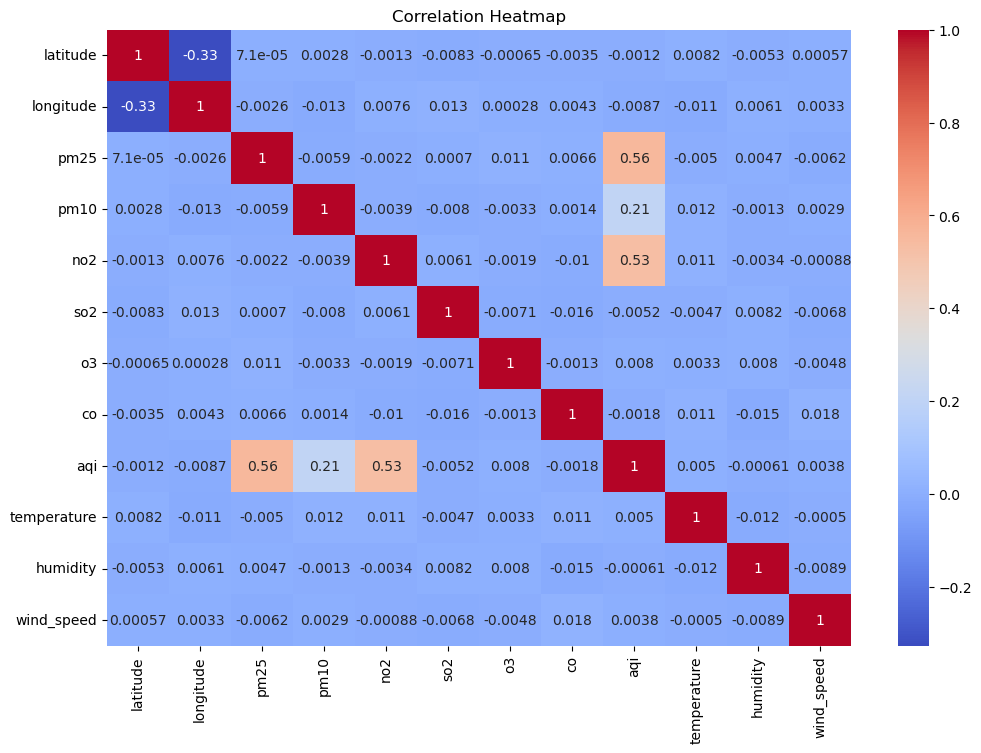

In [12]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

### Features Selection

In [13]:
features = [
    "pm25",
    "pm10",
    "no2",
    "so2",
    "o3",
    "co",
    "aqi",
    "temperature",
    "humidity",
    "wind_speed"
]

In [14]:
X = df[features]

In [15]:
X.head()

,pm25,pm10,no2,so2,o3,co,aqi,temperature,humidity,wind_speed
0,50.295,108.938,27.998,6.539,52.568,1.096,108,18.504,70.168,3.725
1,32.083,63.043,36.120,4.021,43.536,1.075,90,5.838,80.088,8.969
2,42.250,82.553,26.935,9.538,23.320,0.977,84,31.833,62.783,9.650
3,30.403,79.951,63.536,7.609,31.369,0.230,158,23.140,89.153,8.956
4,21.083,66.423,38.997,6.919,45.615,1.085,97,13.632,76.499,4.017


### Feature Scaling

In [16]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

### K-Means Clustering

In [17]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

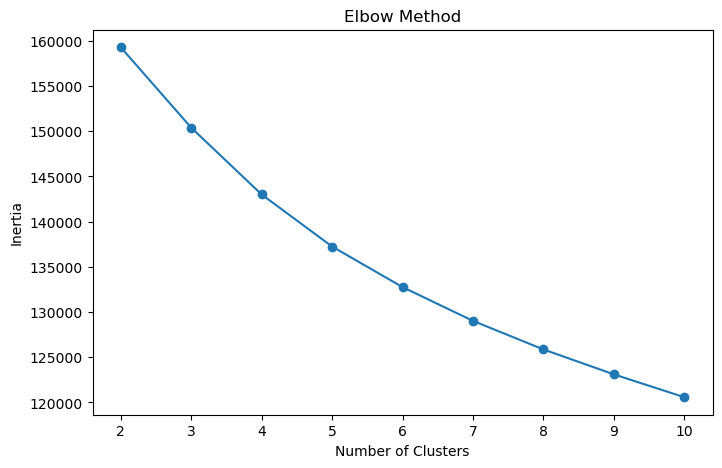

In [18]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), inertia, marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [19]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

#### Evaluation

In [23]:
silhouette_kmeans = silhouette_score(
    X_scaled,
    kmeans_labels
)

print("K-Means Silhouette Score:",
      silhouette_kmeans)

K-Means Silhouette Score: 0.07799843958654354


In [24]:
db_kmeans = davies_bouldin_score(
    X_scaled,
    kmeans_labels
)

print("K-Means Davies-Bouldin Index:",
      db_kmeans)

K-Means Davies-Bouldin Index: 2.5812196643997622


In [25]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

In [26]:
df["KMeans_Cluster"] = kmeans_labels
df["KMeans_Cluster"].value_counts().sort_index()

KMeans_Cluster
0    3367
1    4148
2    4161
3    3211
4    3113
Name: count, dtype: int64

### Hierarchical Clustering

In [31]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)

hier_labels = hierarchical.fit_predict(X_scaled)

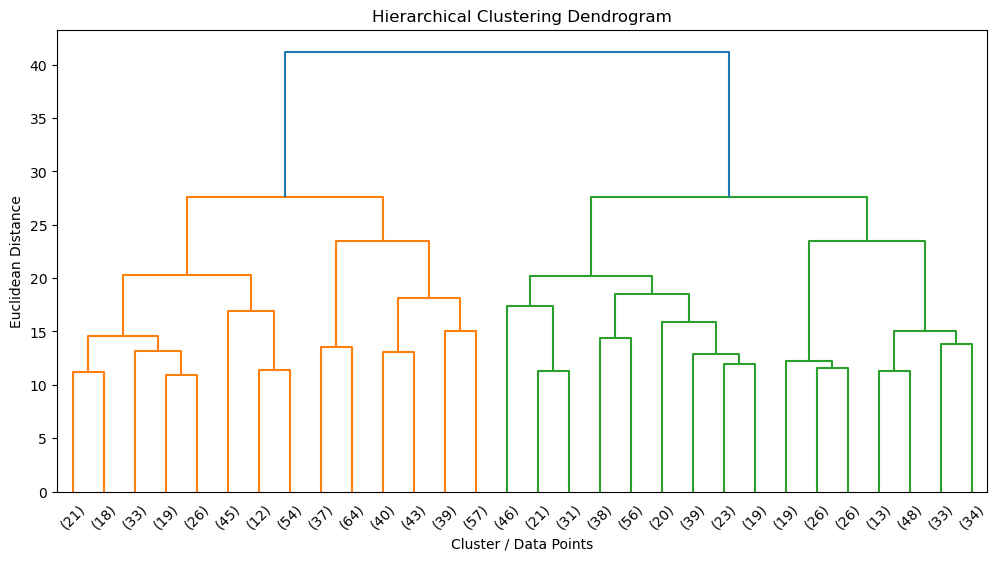

In [33]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Take a sample of the scaled data
sample = X_scaled[:1000]

# Create linkage matrix
linked = linkage(sample, method="ward")

# Plot dendrogram
plt.figure(figsize=(12, 6))

dendrogram(
    linked,
    truncate_mode="lastp",
    p=30
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster / Data Points")
plt.ylabel("Euclidean Distance")

plt.show()

#### Key Insights:

* The dendrogram shows how air quality observations are grouped based on their similarity.
* Observations with smaller distances are more similar and are joined earlier.
* The dendrogram helps determine a suitable number of clusters by observing the distance between groups.

#### Evaluation

In [34]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

hier_silhouette = silhouette_score(
    X_scaled,
    hier_labels
)

hier_db = davies_bouldin_score(
    X_scaled,
    hier_labels
)

print("Hierarchical Silhouette Score:", hier_silhouette)
print("Hierarchical Davies-Bouldin Index:", hier_db)

Hierarchical Silhouette Score: 0.01874750760605853
Hierarchical Davies-Bouldin Index: 3.466644230516575


### DBSCAN Clustering

In [40]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

db_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = db_labels

print("DBSCAN Cluster Counts:")
print(df["DBSCAN_Cluster"].value_counts().sort_index())

DBSCAN Cluster Counts:
DBSCAN_Cluster
-1      3430
 0     14531
 1         6
 2         2
 3         3
 4         1
 5         2
 6         3
 7         3
 8         3
 9         4
 10        4
 11        4
 12        4
Name: count, dtype: int64


### Evaluation

In [41]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

mask = db_labels != -1

if len(set(db_labels[mask])) > 1:

    silhouette_dbscan = silhouette_score(
        X_scaled[mask],
        db_labels[mask]
    )

    db_dbscan = davies_bouldin_score(
        X_scaled[mask],
        db_labels[mask]
    )

    print("DBSCAN Silhouette Score:", silhouette_dbscan)
    print("DBSCAN Davies-Bouldin Index:", db_dbscan)

else:
    print("DBSCAN produced less than 2 clusters.")

DBSCAN Silhouette Score: -0.18494551878250873
DBSCAN Davies-Bouldin Index: 1.0511941926127562


### Model Comparision

In [42]:
results = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Hierarchical",
        "DBSCAN"
    ],
    
    "Silhouette Score": [
        silhouette_kmeans,
        hier_silhouette,
        silhouette_dbscan
    ],
    
    "Davies-Bouldin Index": [
        db_kmeans,
        hier_db,
        db_dbscan
    ]
})

results

,Algorithm,Silhouette Score,Davies-Bouldin Index
0,K-Means,0.077998,2.581220
1,Hierarchical,0.018748,3.466644
2,DBSCAN,-0.184946,1.051194


### Insight:
* K-Means showed better cluster separation than Hierarchical Clustering, based on the Silhouette Score.
* DBSCAN achieved the lowest Davies-Bouldin Index, showing better cluster compactness according to this metric.
* Overall, the three models produced different clustering results, so both evaluation metrics were considered for comparing their performance.

### Cluster Visualization

In [43]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA Shape:", X_pca.shape)

PCA Shape: (18000, 2)


### K-Means cluster visualization

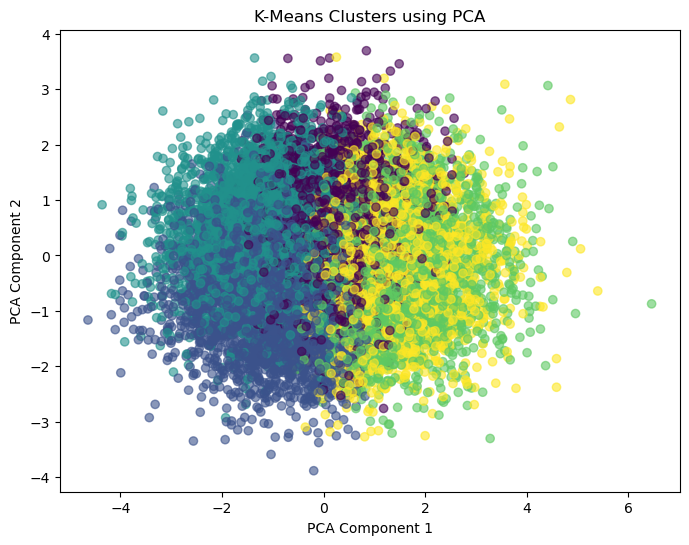

In [44]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    alpha=0.6
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-Means Clusters using PCA")

plt.show()

### Cluster Analysis

### 1. Cluster-Wise Mean

In [45]:
cluster_summary = df.groupby(
    "KMeans_Cluster"
)[features].mean()

cluster_summary

,pm25,pm10,no2,so2,o3,co,aqi,temperature,humidity,wind_speed
KMeans_Cluster,,,,,,,,,,
0,37.825990,102.540992,31.608311,5.657450,49.408220,0.815407,107.950401,21.636467,56.959877,5.212001
1,33.152904,60.309145,26.113707,6.271846,48.094005,0.761373,84.632835,21.742105,59.770685,2.729726
2,32.237550,60.958521,25.685237,6.013741,46.735088,0.828476,83.407594,21.146319,56.236056,7.773994
3,65.552687,66.472104,29.209054,6.075176,49.230620,0.806119,130.616319,20.990717,58.129891,5.329686
4,37.627975,64.321209,51.905488,6.117676,47.149426,0.793871,129.336974,22.087137,57.337713,5.389484


### Insight:
* Cluster 3 has the highest PM2.5 and AQI values, indicating relatively higher pollution levels.
* Cluster 0 has the highest PM10 level, while Cluster 4 has the highest NO2 level.
* Clusters 1 and 2 show relatively lower AQI values compared with Clusters 3 and 4.

## Pipeline Development

### 1. Create Pipeline

In [46]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

final_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(
        n_clusters=5,
        random_state=42,
        n_init=10
    ))
])

final_pipeline.fit(X)

Pipeline(steps=[('scaler', StandardScaler()),
                ('kmeans', KMeans(n_clusters=5, n_init=10, random_state=42))])

### 2. Test Pipeline

In [47]:
final_clusters = final_pipeline.predict(X)

print("Pipeline created successfully.")
print("Number of clusters:", len(set(final_clusters)))

Pipeline created successfully.
Number of clusters: 5


### 3. Export Pipeline

In [48]:
import joblib

joblib.dump(
    final_pipeline,
    "air_quality_clustering_pipeline.pkl"
)

print("Pipeline saved successfully.")

Pipeline saved successfully.


### Conclusion

This project successfully applied unsupervised machine learning techniques to analyze global air quality data. K-Means, Hierarchical Clustering, and DBSCAN were used to identify natural patterns and groups in the dataset. The clustering results were evaluated using Silhouette Score and Davies-Bouldin Index. The analysis showed different pollution characteristics across the identified clusters, providing useful insights into air quality patterns.